# Лабораторная работа 6

Тема: **Оптимизация и скорость сходимости: шаг обучения и выбор оптимизатора**  
Цель: на одной и той же модели и датасете (MNIST + простой MLP) **экспериментально** исследовать, как ведут себя разные значения `learning_rate` и разные оптимизаторы (SGD, SGD+Momentum, Adam), и сформулировать свои практические правила выбора.

> Этот ноутбук предназначен именно для вашей самостоятельной работы.  
> Его структура и код — каркас, а содержание (графики, комментарии, выводы) должны отражать **ваши эксперименты и ваш стиль объяснения**.
> Если вы попытаетесь автоматически сгенерировать текст целиком, это будет заметно по общей, оторванной от ваших графиков формулировке.


## 1. Ваши ожидания до экспериментов

Прежде чем смотреть на реальные кривые, зафиксируйте, что вы **ожидаете** увидеть.

Ответьте своими словами:
1. Что, по вашему интуитивному ощущению, происходит с обучением при **очень маленьком** шаге (`lr`): по loss, по времени сходимости, по точности?  
2. Что может пойти не так при **слишком большом** шаге (`lr`), если смотреть на графики loss/accuracy?  
3. Чем вы ожидаете, что будет отличаться поведение **SGD**, **SGD с momentum** и **Adam** на задаче вроде MNIST (скорость сходимости, чувствительность к выбору lr, «рывки» на графиках и т.п.)?

Напишите ответы в свободной форме (6–10 предложений). Важно, чтобы это были именно ваши формулировки, а не пересказ учебника.


In [3]:
expectations_text = """1. Если learning rate очень маленький, то обучение будет идти очень медленно. loss будет уменьшаться, но очень постепенно и потребуется много эпох, чтобы достичь хорошей точности. При этом графики будут достаточно плавными и стабильными.
2. Если learning rate слишком большой, то обучение может стать нестабильным. loss может начать сильно колебаться или даже расти, а accuracy прыгать. В худшем случае модель вообще не сможет сойтись.
3. Я ожидаю, что обычный SGD будет обучаться медленнее и требовать более аккуратного подбора lr. SGD с momentum должен сходиться быстрее и более плавно, потому что учитывает предыдущие шаги. Adam, скорее всего, будет самым удобным, он должен быстро сходиться и быть менее чувствительным к выбору lr."""
print(expectations_text)

1. Если learning rate очень маленький, то обучение будет идти очень медленно. loss будет уменьшаться, но очень постепенно и потребуется много эпох, чтобы достичь хорошей точности. При этом графики будут достаточно плавными и стабильными.
2. Если learning rate слишком большой, то обучение может стать нестабильным. loss может начать сильно колебаться или даже расти, а accuracy прыгать. В худшем случае модель вообще не сможет сойтись.
3. Я ожидаю, что обычный SGD будет обучаться медленнее и требовать более аккуратного подбора lr. SGD с momentum должен сходиться быстрее и более плавно, потому что учитывает предыдущие шаги. Adam, скорее всего, будет самым удобным, он должен быстро сходиться и быть менее чувствительным к выбору lr.


## 2. Импорт библиотек и настройка среды

Здесь всё стандартно:
- импорт PyTorch, torchvision и вспомогательных библиотек;
- фиксация `seed` (одно число, которое вы сможете назвать на защите);
- определение устройства (`cpu` или `cuda`).


In [1]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

# ВАШ ЛИЧНЫЙ SEED (можете выбрать любое число, но потом не меняйте его без причины)
MY_SEED = 11
torch.manual_seed(MY_SEED)
np.random.seed(MY_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Устройство:", device)
print("MY_SEED =", MY_SEED)

Устройство: cpu
MY_SEED = 11


## 3. Данные MNIST и DataLoader

Используем набор рукописных цифр MNIST.  
Ваша задача:
- задать трансформации (как минимум `ToTensor` + нормализация);
- загрузить обучающую и тестовую части;
- создать `DataLoader` с разумным `batch_size`.

Размер батча вы выбираете сами (например, 64 или 128), главное потом объяснить выбор по-человечески: чем он удобен именно для этой работы.


In [2]:
batch_size = 128  # TODO: поменять и прокомментировать выбор в выводах

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform,
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("train size =", len(train_dataset))
print("test size  =", len(test_dataset))
print("batch_size =", batch_size)

100%|██████████| 9.91M/9.91M [00:00<00:00, 39.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.13MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 9.64MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.7MB/s]


train size = 60000
test size  = 10000
batch_size = 128


Если вы хотите для спокойствия посмотреть на пару примеров изображений — можете добавить сюда небольшой блок визуализации (по образцу ЛР4–5). Это не обязательно, но иногда помогает ощутить задачу глазами.


## 4. Модель (фиксированная для всех экспериментов)

Чтобы сравнение оптимизаторов и `learning_rate` было честным, архитектура модели должна оставаться **одна и та же** во всех прогонах.

Возьмём простой MLP:
- вход: 28×28 → разворачиваем в вектор длины 784;
- два скрытых слоя с ReLU (например, 256 и 128 нейронов);
- выход: 10 логитов (по одному на цифру 0–9).

Эту архитектуру **не меняем** в рамках лабораторной (если измените — **обязательно явно зафиксируйте это в отчёте**).


In [3]:
class SimpleMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.net = nn.Sequential(
            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.net(x)

print(SimpleMLP())

SimpleMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (net): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)


## 5. Общие функции обучения и оценки

Напишем функции `train_one_epoch` и `evaluate`.  
Их вы использовали в прошлых работах; сейчас они понадобятся, чтобы собирать **историю** обучения для разных конфигураций.


In [4]:
criterion = nn.CrossEntropyLoss()

def train_one_epoch(model, dataloader, optimizer, device):
    model.train()
    running_loss = 0.0
    running_correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        running_correct += (preds == labels).sum().item()
        total += images.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total
    return epoch_loss, epoch_acc


def evaluate(model, dataloader, device):
    model.eval()
    running_loss = 0.0
    running_correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            running_correct += (preds == labels).sum().item()
            total += images.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total
    return epoch_loss, epoch_acc

print("Функции train_one_epoch и evaluate определены.")

Функции train_one_epoch и evaluate определены.


## 6. Универсальная функция запуска одного эксперимента

Чтобы не копировать один и тот же код для разных настроек, напишем функцию `run_experiment`, которая:
- создаёт новую модель `SimpleMLP`;
- инициализирует оптимизатор (SGD / SGD+Momentum / Adam) с нужными параметрами;
- обучает модель `num_epochs` эпох;
- возвращает историю значений `train_loss`, `train_acc`, `test_loss`, `test_acc`.

Такой формат удобно использовать для честного сравнения разных конфигураций.


In [5]:
def run_experiment(config_name, optimizer_class, optimizer_kwargs,
                   num_epochs=8):
    print("\n=== Конфигурация:", config_name, "===")

    model = SimpleMLP().to(device)
    optimizer = optimizer_class(model.parameters(), **optimizer_kwargs)

    history = {
        "train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": []
    }

    for epoch in range(1, num_epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, device)
        test_loss, test_acc = evaluate(model, test_loader, device)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)

        print(f"Эпоха {epoch}/{num_epochs} | "
              f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
              f"test_loss={test_loss:.4f}, test_acc={test_acc:.4f}")

    return history

print("Функция run_experiment готова.")

Функция run_experiment готова.


## 7. Набор конфигураций для сравнения

Рекомендуемый набор (можете расширить):

- `SGD lr=0.001` — заведомо небольшой шаг;  
- `SGD lr=0.01` — разумный кандидат;  
- `SGD lr=0.5` — намеренно большой шаг, чтобы увидеть нестабильность;  
- `SGD lr=0.01, momentum=0.9` — добавляем momentum и смотрим, что изменится;  
- `Adam lr=0.001` — «типичная» настройка для Adam.

Число эпох выберите так, чтобы кривые успели чуть-чуть «устаканиться» (например, 8–12 эпох).


In [6]:
num_epochs = 10  # учитывайте время обучения

histories = []
labels = []

# 1. SGD с маленьким шагом
h_sgd_small = run_experiment(
    config_name="SGD lr=0.001",
    optimizer_class=torch.optim.SGD,
    optimizer_kwargs={"lr": 0.001},
    num_epochs=num_epochs
)
histories.append(h_sgd_small)
labels.append("SGD 0.001")

# 2. SGD с "разумным" шагом
h_sgd_mid = run_experiment(
    config_name="SGD lr=0.01",
    optimizer_class=torch.optim.SGD,
    optimizer_kwargs={"lr": 0.01},
    num_epochs=num_epochs
)
histories.append(h_sgd_mid)
labels.append("SGD 0.01")

# 3. SGD с большим шагом
h_sgd_big = run_experiment(
    config_name="SGD lr=0.5",
    optimizer_class=torch.optim.SGD,
    optimizer_kwargs={"lr": 0.5},
    num_epochs=num_epochs
)
histories.append(h_sgd_big)
labels.append("SGD 0.5")

# 4. SGD с momentum
h_sgdm = run_experiment(
    config_name="SGD lr=0.01, momentum=0.9",
    optimizer_class=torch.optim.SGD,
    optimizer_kwargs={"lr": 0.01, "momentum": 0.9},
    num_epochs=num_epochs
)
histories.append(h_sgdm)
labels.append("SGD+mom 0.01")

# 5. Adam
h_adam = run_experiment(
    config_name="Adam lr=0.001",
    optimizer_class=torch.optim.Adam,
    optimizer_kwargs={"lr": 0.001},
    num_epochs=num_epochs
)
histories.append(h_adam)
labels.append("Adam 0.001")

# 6. TODO: предложите свой вариант


=== Конфигурация: SGD lr=0.001 ===
Эпоха 1/10 | train_loss=2.2177, train_acc=0.2952, test_loss=2.1242, test_acc=0.5304
Эпоха 2/10 | train_loss=2.0075, train_acc=0.6237, test_loss=1.8533, test_acc=0.6921
Эпоха 3/10 | train_loss=1.6766, train_acc=0.7034, test_loss=1.4596, test_acc=0.7354
Эпоха 4/10 | train_loss=1.2836, train_acc=0.7560, test_loss=1.0879, test_acc=0.7925
Эпоха 5/10 | train_loss=0.9730, train_acc=0.8051, test_loss=0.8394, test_acc=0.8290
Эпоха 6/10 | train_loss=0.7769, train_acc=0.8322, test_loss=0.6892, test_acc=0.8486
Эпоха 7/10 | train_loss=0.6568, train_acc=0.8484, test_loss=0.5956, test_acc=0.8607
Эпоха 8/10 | train_loss=0.5791, train_acc=0.8598, test_loss=0.5330, test_acc=0.8694
Эпоха 9/10 | train_loss=0.5259, train_acc=0.8677, test_loss=0.4886, test_acc=0.8763
Эпоха 10/10 | train_loss=0.4872, train_acc=0.8735, test_loss=0.4560, test_acc=0.8806

=== Конфигурация: SGD lr=0.01 ===
Эпоха 1/10 | train_loss=1.1576, train_acc=0.7271, test_loss=0.4729, test_acc=0.8745
Эпох

## 8. Визуальное сравнение кривых для разных конфигураций

Теперь важно **на одном графике** увидеть, как ведут себя `train/test loss` и `train/test accuracy` для разных настроек.  
Это поможет сформировать интуицию, а не просто запомнить «Adam хороший, SGD плохой».


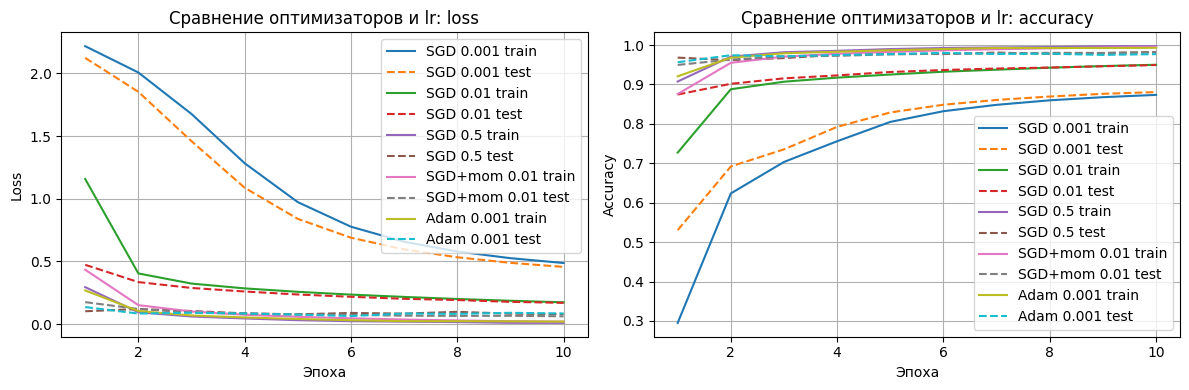

In [7]:
def plot_histories(histories, labels, title_prefix=""):
    plt.figure(figsize=(12, 4))

    # Loss
    plt.subplot(1, 2, 1)
    for hist, label in zip(histories, labels):
        epochs = np.arange(1, len(hist["train_loss"]) + 1)
        plt.plot(epochs, hist["train_loss"], label=f"{label} train")
        plt.plot(epochs, hist["test_loss"], linestyle="--", label=f"{label} test")
    plt.xlabel("Эпоха")
    plt.ylabel("Loss")
    plt.title(title_prefix + "loss")
    plt.grid(True)
    plt.legend()

    # Accuracy
    plt.subplot(1, 2, 2)
    for hist, label in zip(histories, labels):
        epochs = np.arange(1, len(hist["train_acc"]) + 1)
        plt.plot(epochs, hist["train_acc"], label=f"{label} train")
        plt.plot(epochs, hist["test_acc"], linestyle="--", label=f"{label} test")
    plt.xlabel("Эпоха")
    plt.ylabel("Accuracy")
    plt.title(title_prefix + "accuracy")
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_histories(histories, labels, title_prefix="Сравнение оптимизаторов и lr: ")

## 9. Анализ результатов (самая важная часть)

Теперь нужно **словами** описать то, что вы увидели.  
Не переписывайте теорию про оптимизаторы — опирайтесь именно на свои графики и числа.

Попробуйте в одном связанном тексте ответить на такие вопросы:

- Как выглядели кривые для `SGD lr=0.001`: насколько медленно росла точность, успела ли она выйти на разумный уровень за `num_epochs`?  
- Что происходило при `SGD lr=0.5`: были ли скачки loss, «разброс» accuracy, признаки расходимости?  
- Как вёл себя `SGD lr=0.01`: показался ли вам этот шаг «рабочим компромиссом» между скоростью и стабильностью?  
- Что дал `momentum`: стало ли обучение более ровным/быстрым, изменилась ли финальная test accuracy по сравнению с чистым SGD?  
- Как отличался `Adam`: быстрее ли он выходил на высокую точность, как вёл себя test loss, было ли переобучение?

Упоминайте конкретные числа (например, test accuracy на последней эпохе для разных конфигураций) и форму кривых (плавные/рывковые, раннее насыщение и т. п.).


In [8]:
analysis_text = """По экспериментам очень хорошо видно, насколько сильно на обучение влияет выбор learning rate и оптимизатора.
Для SGD с lr=0.001 обучение шло слишком медленно. train accuracy выросла только с 0.2952 до 0.8735, а test accuracy с 0.5304 до 0.8806 за 10 эпох. Кривые при этом были плавными, но модель явно не успела выйти на хороший уровень качества.
Для SGD с lr=0.5 ситуация оказалась совсем другой. Уже на первой эпохе test accuracy была 0.9681, а дальше модель быстро дошла до 0.9822. Но по test loss и test accuracy видно, что обучение было менее стабильным. например, test accuracy менялась от 0.9617 до 0.9809 и потом снова немного падала, то есть большой шаг даёт быстрый прогресс, но добавляет колебания.
SGD с lr=0.01 показал себя как хороший рабочий вариант. Обучение шло заметно быстрее, чем при lr=0.001, и при этом без сильных скачков. К последней эпохе test accuracy достигла 0.9493, а loss убывал достаточно ровно, поэтому такой шаг можно считать стабильным и разумным.
Momentum заметно улучшил обычный SGD с тем же lr=0.01. Уже на первой эпохе test accuracy была 0.9496, а к 10-й эпохе выросла до 0.9817. По сравнению с обычным SGD 0.01 это намного лучше и по скорости, и по итоговому качеству. Кривые тоже выглядели более гладкими, то есть momentum действительно помог ускорить и стабилизировать обучение.
Adam с lr=0.001 тоже очень быстро вышел на высокую точность, уже на 2 эпохе test accuracy была 0.9742, а лучший результат доходил до 0.9800. Но дальше test loss и test accuracy начали немного колебаться, например на 7–10 эпохах качество уже не улучшалось стабильно. Это похоже на лёгкое переобучение
В итоге хуже всего себя показал слишком маленький шаг, потому что обучение шло слишком медленно. Обычный SGD с lr=0.01 оказался нормальным базовым вариантом, но лучше всего выглядел SGD с momentum, потому что он дал очень высокую точность и при этом вёл себя достаточно стабильно. Adam тоже оказался сильным вариантом, но в запусках momentum дал чуть более приятное и предсказуемое поведение кривых."""
print(analysis_text)

По экспериментам очень хорошо видно, насколько сильно на обучение влияет выбор learning rate и оптимизатора. 
Для SGD с lr=0.001 обучение шло слишком медленно. train accuracy выросла только с 0.2952 до 0.8735, а test accuracy с 0.5304 до 0.8806 за 10 эпох. Кривые при этом были плавными, но модель явно не успела выйти на хороший уровень качества.
Для SGD с lr=0.5 ситуация оказалась совсем другой. Уже на первой эпохе test accuracy была 0.9681, а дальше модель быстро дошла до 0.9822. Но по test loss и test accuracy видно, что обучение было менее стабильным. например, test accuracy менялась от 0.9617 до 0.9809 и потом снова немного падала, то есть большой шаг даёт быстрый прогресс, но добавляет колебания.
SGD с lr=0.01 показал себя как хороший рабочий вариант. Обучение шло заметно быстрее, чем при lr=0.001, и при этом без сильных скачков. К последней эпохе test accuracy достигла 0.9493, а loss убывал достаточно ровно, поэтому такой шаг можно считать стабильным и разумным.
Momentum заметно 

## 10. Итоговые практические выводы

В конце сформулируйте короткое резюме (5–8 предложений), как будто вы объясняете младшим курсам, **что вы вынесли из этой лабораторной**:

- Какие диапазоны `learning_rate` для SGD вы теперь считаете «слишком маленькими», «рабочими» и «слишком агрессивными» — именно на примере этой задачи.  
- В каких случаях вы бы использовали SGD с momentum, а в каких — достаточно обычного SGD.  
- Когда лично вы после этой работы предпочли бы Adam, а когда — всё-таки остались бы на SGD/SGD+Momentum (например, из-за понятности поведения, чувствительности к lr и т.п.).

Важно, чтобы здесь звучал ваш голос и ссылка на ваш опыт, а не абстрактные фразы про «Adam обычно лучше».


In [9]:
final_conclusion = """По результатам работы я увидела, что для SGD learning rate сильно влияет на качество обучения. Значение 0.001 оказалось слишком маленьким,модель обучается очень медленно и не успевает достичь хорошей точности. Значение 0.01 показало себя как рабочее, обучение идёт стабильно и даёт нормальный результат. Слишком большой шаг (0.5) даёт быстрый рост качества, но делает обучение менее стабильным.
SGD с momentum оказался лучше обычного SGD, так как он быстрее сходится и даёт более высокую точность, поэтому я бы чаще использовала именно его, а не чистый SGD.
Adam показал очень быструю сходимость и высокую точность, поэтому я бы использовала его, если нужно быстро получить хороший результат без долгой настройки. Но SGD с momentum даёт более предсказуемое поведение, поэтому в задачах, где важен контроль обучения, я бы выбрала именно его."""
print(final_conclusion)

По результатам работы я увидела, что для SGD learning rate сильно влияет на качество обучения. Значение 0.001 оказалось слишком маленьким,модель обучается очень медленно и не успевает достичь хорошей точности. Значение 0.01 показало себя как рабочее, обучение идёт стабильно и даёт нормальный результат. Слишком большой шаг (0.5) даёт быстрый рост качества, но делает обучение менее стабильным.
SGD с momentum оказался лучше обычного SGD, так как он быстрее сходится и даёт более высокую точность, поэтому я бы чаще использовала именно его, а не чистый SGD.
Adam показал очень быструю сходимость и высокую точность, поэтому я бы использовала его, если нужно быстро получить хороший результат без долгой настройки. Но SGD с momentum даёт более предсказуемое поведение, поэтому в задачах, где важен контроль обучения, я бы выбрала именно его.
